In [1]:
import seaborn as sns
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

Path("diagrams").mkdir(exist_ok=True)

In [2]:
result_path = Path("../results/downstream_task")
bias_types = ["less_positive_class"]
less_bias_strengths = ["0.1"]
method_name_replacer = {"mrs-forest": "MRS",  
                        "fw-mrs-temperature": "FW-MRS",
                        "fw-mrs-temperature-svm": "FW-MRS$_{SVM}$",
                        }
data_set_replacer = {
                    "diabetes": "Diabetes", 
                    "folktables_employment": "Employment", 
                    "folktables_income": "Income",
                    "bank_marketing": "Bank Marketing",
                    "hr_analytics": "HR Analytic", 
                    "german_credit": "German Credit", 
                    "breast_cancer": "Breast Cancer", 
                    "loan_prediction": "Loan",
                    }

## Plot per temperature

In [3]:
dict_list = []
auroc_dict_list = []

for dataset in data_set_replacer.keys():
    for bias_type in bias_types:
        for method in ("fw-mrs-temperature", "fw-mrs-temperature-svm"):
            for bias_strength in less_bias_strengths:
                dropped_samples_file_name = result_path / dataset / bias_type /  bias_strength/ method / "validation/dropped_samples_val_dict.json"
                try:
                    dropped_samples_file = pd.read_json(str(dropped_samples_file_name), orient="records", typ="series", convert_axes=False)
                except FileNotFoundError:
                    continue
                auroc_file_name = result_path / dataset / bias_type /  bias_strength/ method / "validation"/ "auroc_val_dict.json"
                auroc_file = pd.read_json(str(auroc_file_name), orient="records", typ="series", convert_axes=False)
                dict_list.append(
                    {
                        "Dropped Samples": dropped_samples_file,
                        "Data Set": dataset,
                        "Method": method,
                        "bias_type": bias_type,
                        "bias_strength": bias_strength,
                    }
                                )
                auroc_dict_list.append(
                    {
                        "AUROC": auroc_file
                }
                )

result_df = pd.DataFrame(data=dict_list)
auroc_result_df = pd.DataFrame(data=auroc_dict_list)
result_df = pd.concat([result_df.drop(['Dropped Samples'], axis=1),result_df["Dropped Samples"].apply(pd.Series)], axis=1)

temperatures = list(result_df.columns.drop(["Data Set", "Method", "bias_type", "bias_strength"]))

result_df = result_df.explode(temperatures)
result_df = result_df.melt(var_name="Temperature", value_name="Dropped Samples", value_vars=temperatures, 
                        id_vars=result_df.drop(columns=temperatures).columns)
auroc_result_df = pd.concat([auroc_result_df.drop(['AUROC'], axis=1), auroc_result_df["AUROC"].apply(pd.Series)], axis=1)
auroc_result_df = auroc_result_df.explode(temperatures)
auroc_result_df = auroc_result_df.melt(var_name="Temperature", value_name="AUROC", value_vars=temperatures)

result_df = pd.concat([result_df, auroc_result_df["AUROC"]], axis=1)

In [4]:
result_df

,Data Set,Method,bias_type,bias_strength,Temperature,Dropped Samples,AUROC
0,diabetes,fw-mrs-temperature,less_positive_class,0.1,0.001,20,0.701477
1,diabetes,fw-mrs-temperature,less_positive_class,0.1,0.001,5,0.736744
2,diabetes,fw-mrs-temperature,less_positive_class,0.1,0.001,25,0.751444
3,diabetes,fw-mrs-temperature,less_positive_class,0.1,0.001,0,0.7728
4,diabetes,fw-mrs-temperature,less_positive_class,0.1,0.001,5,0.652587
...,...,...,...,...,...,...,...
7114,loan_prediction,fw-mrs-temperature-svm,less_positive_class,0.1,0.5,9,0.41621
7115,loan_prediction,fw-mrs-temperature-svm,less_positive_class,0.1,0.5,3,0.55741
7116,loan_prediction,fw-mrs-temperature-svm,less_positive_class,0.1,0.5,11,0.617688
7117,loan_prediction,fw-mrs-temperature-svm,less_positive_class,0.1,0.5,4,0.599937


## Load MRS

In [5]:
mrs_dict_list = []
mrs_auroc_dict_list = []

for dataset in data_set_replacer.keys():
    for bias_type in bias_types:
        for bias_strength in less_bias_strengths:
            dropped_samples_file_name = result_path / dataset / bias_type /  bias_strength/ "mrs-forest" / "validation" / "dropped_samples_individual_val_dict.json"
            auroc_file_name = result_path / dataset / bias_type /  bias_strength/ "mrs-forest" / "validation"/ "auroc_individual_val_dict.json"
            try:
                dropped_samples_file = pd.read_json(str(dropped_samples_file_name), orient="records", typ="series", convert_axes=False)
            except FileNotFoundError:
                    continue
            auroc_file = pd.read_json(str(auroc_file_name), orient="records", typ="series", convert_axes=False)
            mrs_dict_list.append(
                {
                    "Dropped Samples": dropped_samples_file["0.0"]["0.0"],
                    "Data Set": dataset,
                    "Method": "MRS",
                    "bias_type": bias_type,
                    "bias_strength": bias_strength,
                }
                            )
            mrs_auroc_dict_list.extend(auroc_file["0.0"]["0.0"])
mrs_result_df = pd.DataFrame(data=mrs_dict_list)
mrs_result_df = mrs_result_df.explode("Dropped Samples")
mrs_result_df["Temperature"] = "MRS"
mrs_result_df["AUROC"] = mrs_auroc_dict_list

In [6]:
result_df = pd.concat([result_df, mrs_result_df], axis=0)

In [7]:
result_df["Dropped Samples"] = result_df["Dropped Samples"].astype(float)
result_df = result_df.replace(method_name_replacer)
result_df = result_df.replace(data_set_replacer)
result_df.loc[result_df["Data Set"] == "Employment", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "Employment", "Dropped Samples"] / 1408)
result_df.loc[result_df["Data Set"] == "Income", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "Income", "Dropped Samples"] / 1448)
result_df.loc[result_df["Data Set"] == "HR Analytic", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "HR Analytic", "Dropped Samples"] / 3048)
result_df.loc[result_df["Data Set"] == "Breast Cancer", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "Breast Cancer", "Dropped Samples"] / 113)
result_df.loc[result_df["Data Set"] == "Loan", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "Loan", "Dropped Samples"] / 72)

result_df.loc[result_df["Data Set"] == "German Credit", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "German Credit", "Dropped Samples"] / 292)
result_df.loc[result_df["Data Set"] == "Diabetes", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "Diabetes", "Dropped Samples"] / 2108)
result_df.loc[result_df["Data Set"] == "Bank Marketing", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "Bank Marketing", "Dropped Samples"] / 2150)

/tmp/ipykernel_2959392/1467280209.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  result_df = result_df.replace(method_name_replacer)


## With AUROC

In [8]:
result_df

,Data Set,Method,bias_type,bias_strength,Temperature,Dropped Samples,AUROC
0,Diabetes,FW-MRS,less_positive_class,0.1,0.001,0.009488,0.701477
1,Diabetes,FW-MRS,less_positive_class,0.1,0.001,0.002372,0.736744
2,Diabetes,FW-MRS,less_positive_class,0.1,0.001,0.011860,0.751444
3,Diabetes,FW-MRS,less_positive_class,0.1,0.001,0.000000,0.772800
4,Diabetes,FW-MRS,less_positive_class,0.1,0.001,0.002372,0.652587
...,...,...,...,...,...,...,...
7,Loan,MRS,less_positive_class,0.1,MRS,0.013889,0.504014
7,Loan,MRS,less_positive_class,0.1,MRS,0.208333,0.555881
7,Loan,MRS,less_positive_class,0.1,MRS,0.138889,0.646744
7,Loan,MRS,less_positive_class,0.1,MRS,0.055556,0.644571


In [9]:
hue_order = (temperatures + ["MRS"])[::-1]

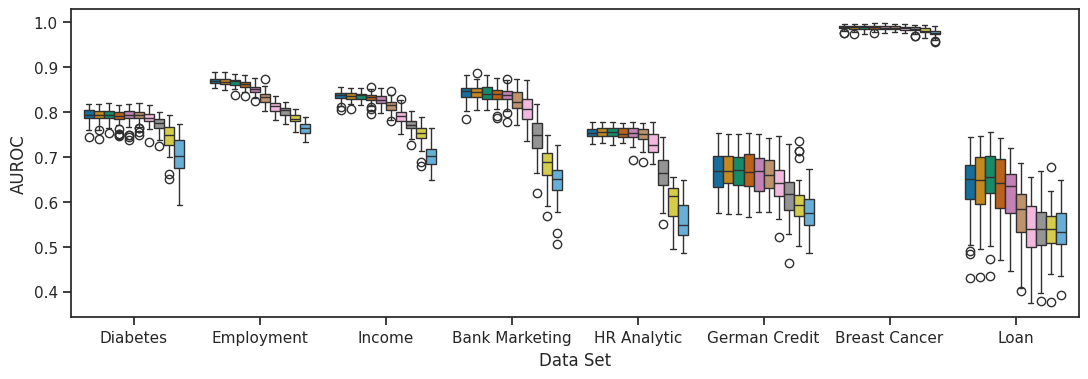

In [10]:
plt.figure(figsize=(13, 4))
ylabel="Relative Dropped Samples (%)"
sns.set_theme(style="ticks", palette="colorblind")
ax = sns.boxplot(data=result_df[result_df["Method"].isin(["MRS", "FW-MRS"])], y="Dropped Samples", x="Data Set", 
            hue="Temperature", legend=True, hue_order=hue_order)
ax.legend(title="Temperature", ncol=2)
ax.set(ylabel=ylabel)
plt.savefig("diagrams/dropped_samples_per_temperature_fixed.pdf", bbox_inches="tight")
plt.clf()

sns.boxplot(data=result_df[result_df["Method"].isin(["MRS", "FW-MRS"])], y="AUROC", x="Data Set", 
            hue="Temperature", legend=False, hue_order=hue_order ).set(ylabel="AUROC")
plt.savefig("diagrams/auroc_per_temperature_fixed.pdf", bbox_inches="tight")

## Plot per method

In [11]:
auroc_file

0.0    {'0.0': [0.6844654007901111, 0.676181980374665...
dtype: object

In [12]:
aurocs = []
auprcs = []
dict_list = []
auroc_dict_list = []
for dataset in data_set_replacer.keys():
    for bias_type in bias_types:
        for method in method_name_replacer.keys():
            for bias_strength in less_bias_strengths:
                dropped_samples_file = result_path / dataset / bias_type /  bias_strength / method / "classification_results" / "dropped_samples.json"
                auroc_file_name = result_path / dataset / bias_type /  bias_strength / method / "classification_results" / "rf_auroc_list.json"
                try:
                    dropped_samples_file = pd.read_json(str(dropped_samples_file), typ="series")
                    auroc_file = pd.read_json(str(auroc_file_name), orient="records", typ="series", convert_axes=False)
                except FileNotFoundError:
                    continue
                dict_list.append(
                    {
                        "Dropped Samples": dropped_samples_file,
                        "Data Set": dataset,
                        "Method": method,
                        "bias_type": bias_type,
                        "bias_strength": bias_strength,
                    }
                                )
                auroc_dict_list.append(
                    {
                        "AUROC": auroc_file
                    }
                                )
result_df = pd.DataFrame(data=dict_list)
auroc_result_df = pd.DataFrame(data=auroc_dict_list)
auroc_result_df = auroc_result_df.explode(column="AUROC", ignore_index=True)
result_df = result_df.explode(column="Dropped Samples", ignore_index=True)
result_df = pd.concat([result_df, auroc_result_df["AUROC"]], axis=1)
result_df = pd.concat([result_df, mrs_result_df], axis=0)
result_df = result_df.replace(method_name_replacer)
result_df = result_df.replace(data_set_replacer)
result_df = result_df.drop(columns=["Temperature"])

/tmp/ipykernel_2959392/2608937365.py:36: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  result_df = result_df.replace(method_name_replacer)


In [13]:
result_df["Dropped Samples"] = result_df["Dropped Samples"].astype(float)
result_df.loc[result_df["Data Set"] == "Employment", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "Employment", "Dropped Samples"] / 1408)
result_df.loc[result_df["Data Set"] == "Income", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "Income", "Dropped Samples"] / 1448)
result_df.loc[result_df["Data Set"] == "HR Analytic", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "HR Analytic", "Dropped Samples"] / 3048)
result_df.loc[result_df["Data Set"] == "Breast Cancer", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "Breast Cancer", "Dropped Samples"] / 113)
result_df.loc[result_df["Data Set"] == "Loan", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "Loan", "Dropped Samples"] / 72)

result_df.loc[result_df["Data Set"] == "German Credit", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "German Credit", "Dropped Samples"] / 292)
result_df.loc[result_df["Data Set"] == "Diabetes", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "Diabetes", "Dropped Samples"] / 2108)
result_df.loc[result_df["Data Set"] == "Bank Marketing", "Dropped Samples"] = (result_df.loc[result_df["Data Set"] == "Bank Marketing", "Dropped Samples"] / 2150)

## Test Results

In [14]:
data_set_order = ["Diabetes", "Employment", "Income", "Bank Marketing", "HR Analytic", "German Credit", "Breast Cancer", "Loan"]

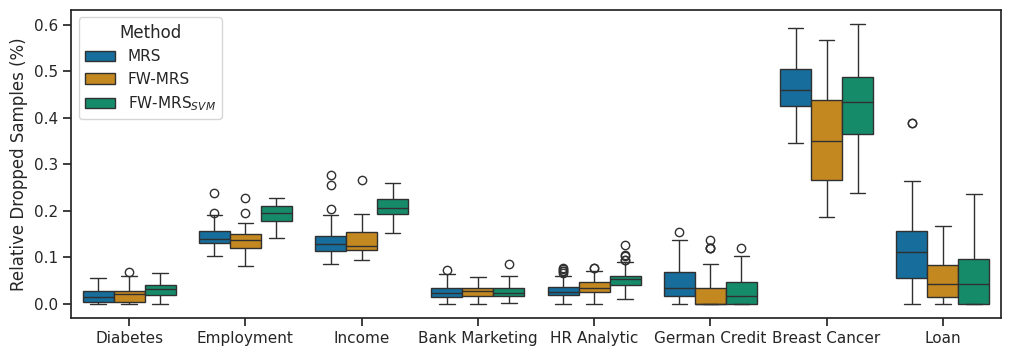

In [15]:
plt.figure(figsize=(12, 4))
sns.boxplot(data=result_df, y="Dropped Samples", x="Data Set", hue="Method",
            order=data_set_order,
            hue_order=method_name_replacer.values()).set(xlabel=None, ylabel="Relative Dropped Samples (%)")
plt.savefig("diagrams/relative_dropped_samples_per_method_complete.pdf", bbox_inches="tight")

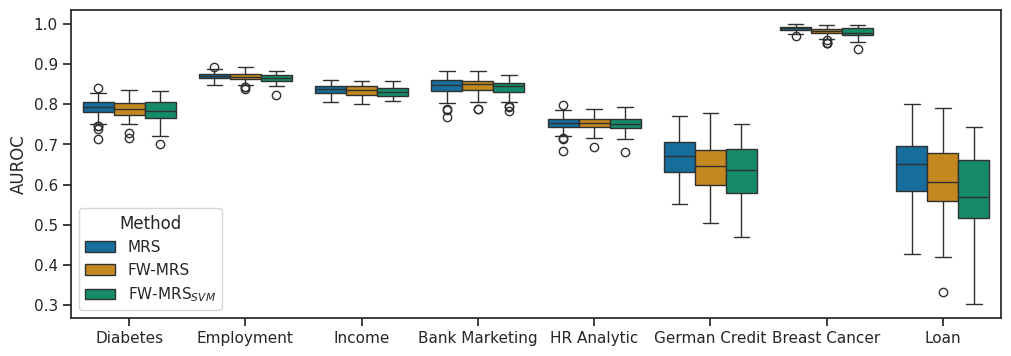

In [16]:
plt.figure(figsize=(12, 4))
sns.boxplot(data=result_df, y="AUROC", x="Data Set", hue="Method",
            order=data_set_order,
            hue_order=method_name_replacer.values()).set(xlabel=None, ylabel="AUROC")
plt.savefig("diagrams/auroc_samples_per_method_complete.pdf", bbox_inches="tight")